In [ ]:
# !pip install polars pandas seaborn matplotlib jupyter
# !pip install pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Данные загружены. Размер: 1000 строк, 20 колонок.
Колонки: ['age', 'eligible', 'financial', 'filed', 'imputed', 'simplified', 'articulated', 'totals_adjustment', 'outlier', 'line_1100', 'line_1110', 'line_1120', 'line_1130', 'line_1140', 'line_1150', 'line_1160', 'line_1170', 'line_1180', 'line_1190', 'line_1200']


,age,eligible,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,line_1100,line_1110,line_1120,line_1130,line_1140,line_1150,line_1160,line_1170,line_1180,line_1190,line_1200
count,1000.000000,1000.000000,1000.0,1000.000000,1000.00000,790.000000,790.000000,790.000000,1000.0,2.990000e+02,34.000000,11.0,11.000000,11.000000,2.460000e+02,12.000000,54.000000,33.000000,3.000000e+01,6.570000e+02
mean,5.079000,0.918000,0.0,0.732000,0.05800,0.421519,0.963291,0.774684,0.0,8.127231e+04,675.235294,0.0,65.000000,187.636364,7.562391e+04,5614.250000,6826.648148,12972.606061,1.602366e+05,7.644273e+06
std,7.564654,0.274502,0.0,0.443139,0.23386,0.494115,0.188165,0.418055,0.0,4.403737e+05,2786.243774,0.0,215.580611,622.319415,3.703789e+05,19150.796718,30960.873938,38714.577058,7.294817e+05,1.950673e+08
min,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,-1.000000e+01
25%,0.000000,1.000000,0.0,0.000000,0.00000,0.000000,1.000000,1.000000,0.0,1.600000e+01,0.000000,0.0,0.000000,0.000000,2.322500e+02,0.000000,0.000000,0.000000,0.000000e+00,1.600000e+01
50%,1.000000,1.000000,0.0,1.000000,0.00000,0.000000,1.000000,1.000000,0.0,9.460000e+02,0.000000,0.0,0.000000,0.000000,2.024000e+03,0.000000,0.000000,125.000000,7.995000e+02,6.380000e+02
75%,9.000000,1.000000,0.0,1.000000,0.00000,1.000000,1.000000,1.000000,0.0,1.163750e+04,44.000000,0.0,0.000000,0.000000,1.368350e+04,0.000000,72.000000,7376.000000,2.873500e+04,6.354000e+03
max,33.000000,1.000000,0.0,1.000000,1.00000,1.000000,1.000000,1.000000,0.0,5.315279e+06,16102.000000,0.0,715.000000,2064.000000,5.100530e+06,66420.000000,200000.000000,214749.000000,4.005650e+06,5.000000e+09


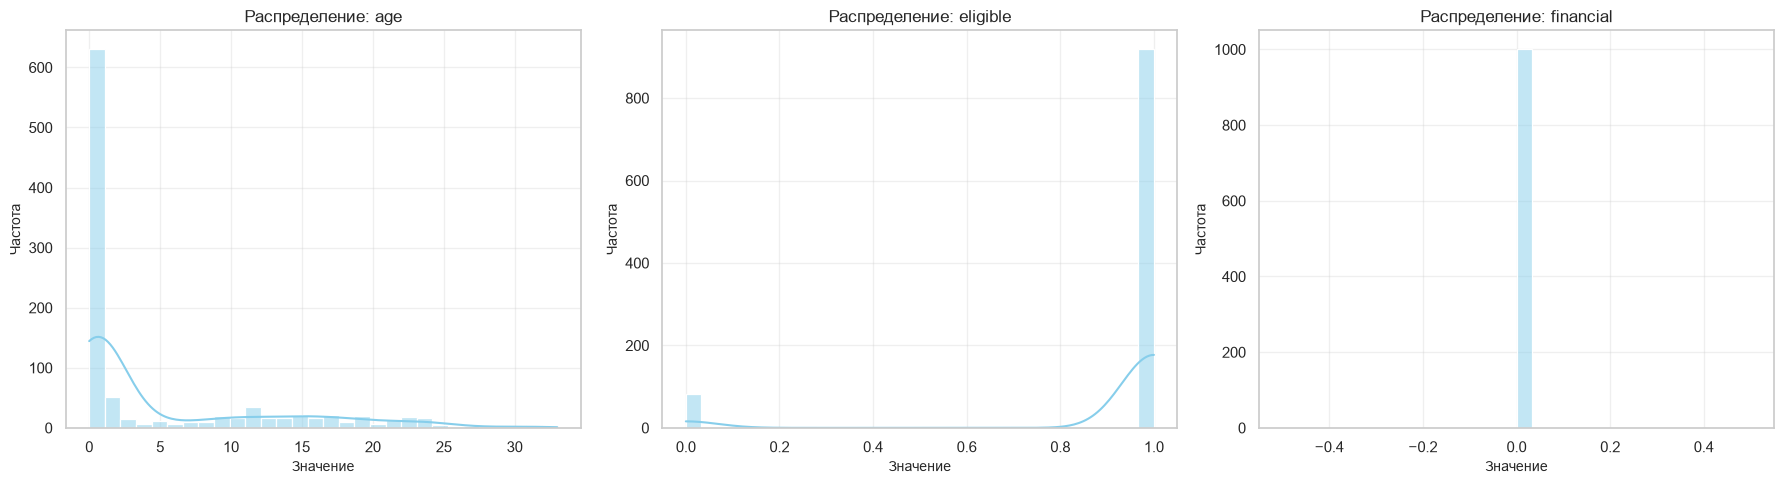

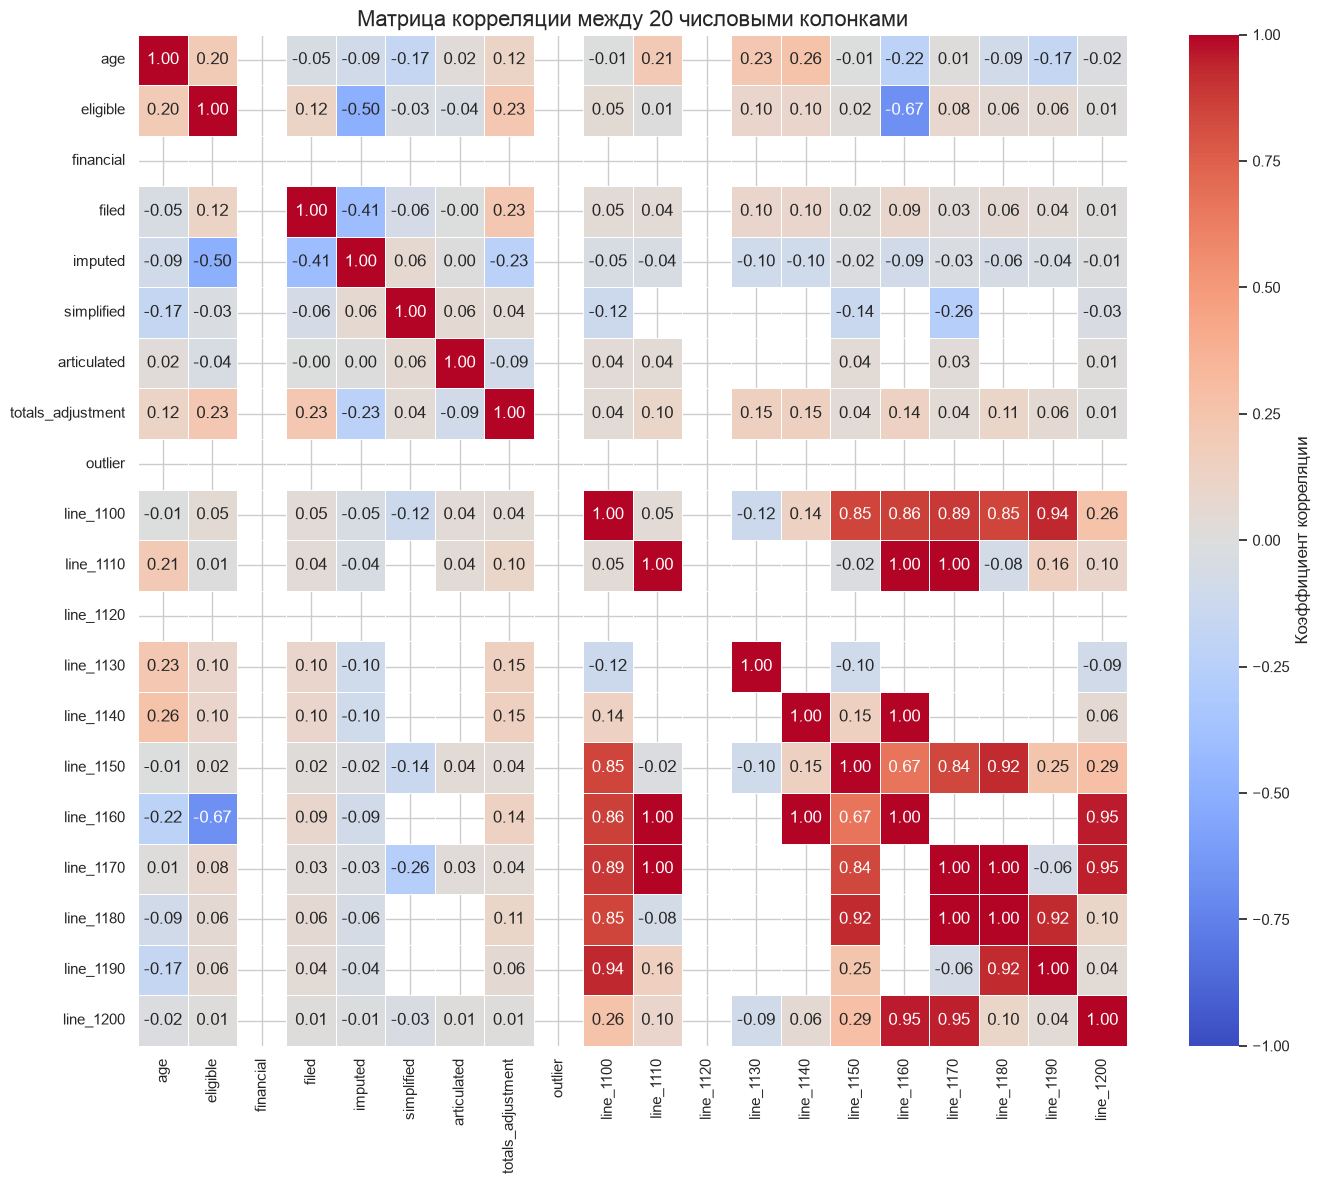


=== Пары с высокой корреляцией (|r| > 0.7) ===
🔹 line_1100 и line_1150: 0.85
🔹 line_1100 и line_1160: 0.86
🔹 line_1100 и line_1170: 0.89
🔹 line_1100 и line_1180: 0.85
🔹 line_1100 и line_1190: 0.94
🔹 line_1110 и line_1160: 1.00
🔹 line_1110 и line_1170: 1.00
🔹 line_1140 и line_1160: 1.00
🔹 line_1150 и line_1170: 0.84
🔹 line_1150 и line_1180: 0.92
🔹 line_1160 и line_1200: 0.95
🔹 line_1170 и line_1180: 1.00
🔹 line_1170 и line_1200: 0.95
🔹 line_1180 и line_1190: 0.92


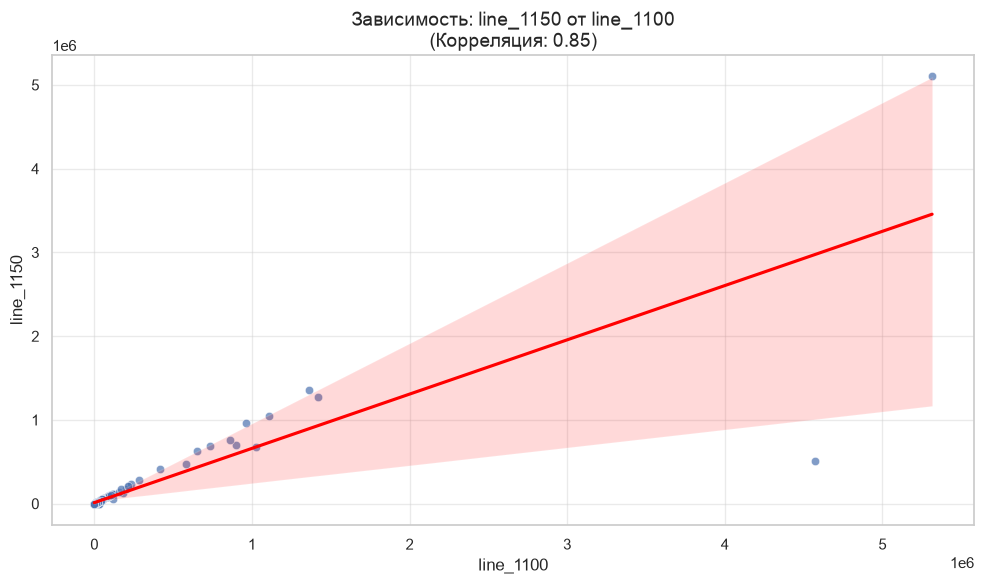

In [1]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

url = "hf://datasets/irlspbru/RFSD/RFSD/year=2023/*.parquet"
df = pl.read_parquet(url, n_rows=1000)

numeric_df = df.select(pl.col(pl.NUMERIC_DTYPES))
cols_to_keep = numeric_df.columns[:20]
df_20 = numeric_df.select(cols_to_keep)

pdf = df_20.to_pandas()

print(f"Данные загружены. Размер: {pdf.shape[0]} строк, {pdf.shape[1]} колонок.")
print(f"Колонки: {pdf.columns.tolist()}")

desc_stats = pdf.describe()
display(desc_stats)

cols_to_plot = pdf.columns[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols_to_plot):
    sns.histplot(pdf[col].dropna(), bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Распределение: {col}', fontsize=12)
    axes[i].set_xlabel('Значение', fontsize=10)
    axes[i].set_ylabel('Частота', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

corr_matrix = pdf.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1,
    cbar_kws={'label': 'Коэффициент корреляции'}
)
plt.title("Матрица корреляции между 20 числовыми колонками", fontsize=16)
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

print("\n=== Пары с высокой корреляцией (|r| > 0.7) ===")
if high_corr_pairs:
    for col1, col2, val in high_corr_pairs:
        print(f"🔹 {col1} и {col2}: {val:.2f}")
else:
    print("Пар с корреляцией > 0.7 не найдено в данном срезе.")

if high_corr_pairs:
    col_x, col_y, corr_val = high_corr_pairs[0]
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=pdf, x=col_x, y=col_y, alpha=0.7)
    sns.regplot(data=pdf, x=col_x, y=col_y, scatter=False, color='red')
    
    plt.title(f'Зависимость: {col_y} от {col_x}\n(Корреляция: {corr_val:.2f})', fontsize=14)
    plt.xlabel(col_x, fontsize=12)
    plt.ylabel(col_y, fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

1. Распределение данных и выбросы

Анализ гистограмм выявил сильную правостороннюю асимметрию в распределении возраста компаний (`age`): подавляющее большинство фирм в выборке — молодые (0–5 лет), при этом существует длинный «хвост» компаний старше 20–30 лет.

2. Высокая корреляция между строками баланса

Матрица корреляции показала исключительно высокую линейную связь (r = 0.85–1.00) между группой колонок `line_1100`, `line_1150`, `line_1160`, `line_1170`, `line_1180`, `line_1190`, `line_1200`. Это строки бухгалтерского баланса, соответствующие внеоборотным и оборотным активам компаний.

Причины высокой корреляции:
- Эффект масштаба: крупные компании имеют пропорционально большие значения по всем статьям баланса одновременно. Выручка, активы, капитал растут синхронно.

3. Выбросы на диаграмме рассеивания

Scatter plot между `line_1150` и `line_1100` наглядно демонстрирует четкую линейную зависимость с одним ярко выраженным выбросом — компанией с аномально высокими значениями, которая сильно отклоняется от общего тренда. Это, вероятно, один из крупнейших игроков рынка, чьи финансовые показатели несопоставимы с остальной выборкой.